<a href="https://colab.research.google.com/github/ananthaaa/DS-lab/blob/main/Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
data = pd.read_csv("winequality-red.csv")

In [ ]:
#a) Perform Exploratory Data Analysis (EDA):
print("First Five Records:")
print(data.head())

First Five Records:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  


In [ ]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [ ]:
print("\nDescriptive Statistics:")
print(data.describe())


Descriptive Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000     

In [ ]:
print("\nWine Quality Distribution:")
print(data["quality"].value_counts().sort_index())


Wine Quality Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


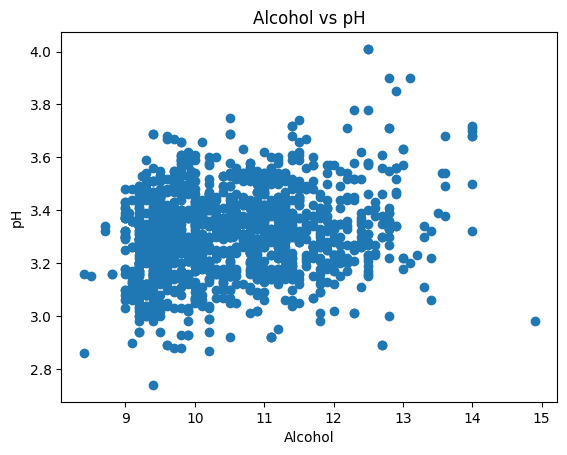

In [ ]:
#b) Visualize the data using:
plt.figure()
plt.scatter(data["alcohol"], data["pH"])
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.title("Alcohol vs pH")
plt.show()


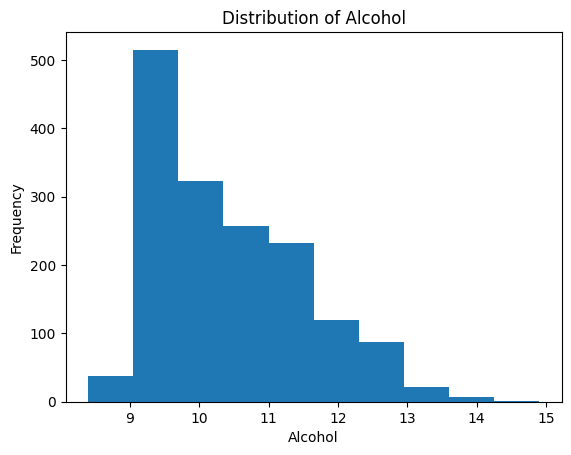

In [ ]:
plt.figure()
plt.hist(data["alcohol"], bins=10)
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.title("Distribution of Alcohol")
plt.show()

<Figure size 640x480 with 0 Axes>

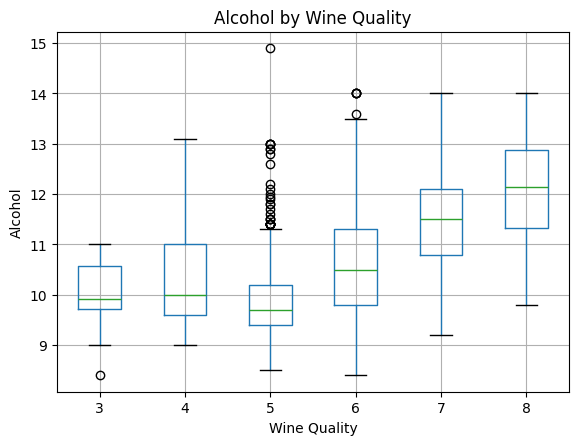

In [ ]:
plt.figure()
data.boxplot(column="alcohol", by="quality")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")
plt.title("Alcohol by Wine Quality")
plt.suptitle("")
plt.show()


In [ ]:
#c) Implement k-NN Classification:
data = data.dropna()

In [ ]:
X = data.drop("quality", axis=1)
y = data["quality"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
k_values = [3, 5, 7, 9, 11]
print("\nAccuracy for Different k Values:")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print("k =", k, "Accuracy =", accuracy)



Accuracy for Different k Values:
k = 3 Accuracy = 0.515625
k = 5 Accuracy = 0.546875
k = 7 Accuracy = 0.55
k = 9 Accuracy = 0.559375
k = 11 Accuracy = 0.571875


In [ ]:
k = int(input("\nEnter the value of k: "))

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy for k =", k, ":", accuracy)


Enter the value of k: 5
Accuracy for k = 5 : 0.546875
